## This Jupyter Notebook aims to understand ERT using pyGIMLi.

### Objectives:
#### 1. Create the main subsurface geometry (domain).
#### 2. Generate random geological features with high or low resistivity.
#### 3. Generate synthetic ERT data using electrodes in pyGIMLi.
#### 4. Save the synthetic data.
#### 5. Use the ERT Manager to invert the data and interpret the subsurface features.
#### 6. Improve the inversion results by incorporating existing geological knowledge of the subsurface.

In [1]:
import pygimli as pg    #import pygimli module
import pygimli.meshtools as mt   #import meshtools to creat geometry

(<Axes: xlabel='$x$ in m'>, None)

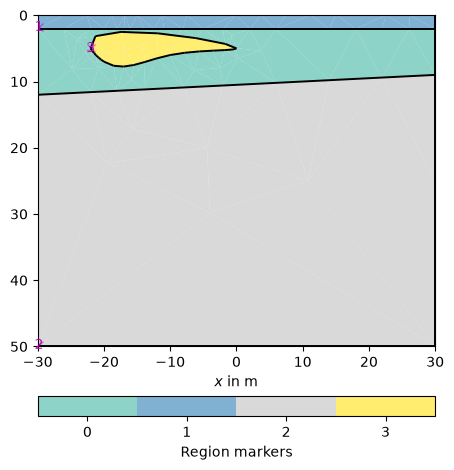

In [2]:
left = 30   #coordinate of left extent of model (in m)
right = 30  #coordinate of right extent of model (in m)
depth = 50  #depth of the model (in m)

# create the model extent
domain = mt.createWorld(start = [-left, 0], 
                        end = [right, -depth], 
                       layers = [-2])

# creat a shape which will have very high resistivity
blob = mt.createPolygon([[-22, -5], [-20, -7], [-10, -6], [0, -5]], 
                       isClosed=True, 
                       addNodes=5,
                       interpolate= 'spline', 
                       marker = 3)
# add an inclined layer
line = mt.createLine(start = [-left, -12], end = [right, -9])
geometry = blob + domain +line
pg.show(geometry)

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x79d27842bf50>)

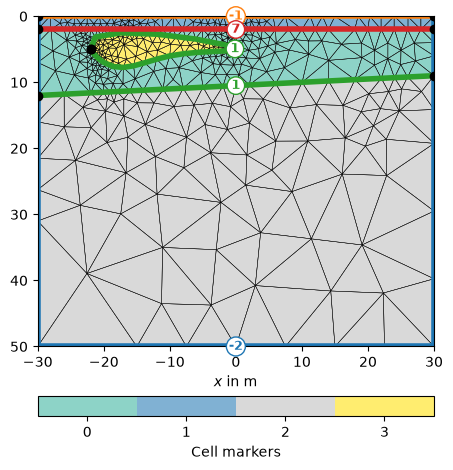

In [3]:
#create mesh
mesh = mt.createMesh(geometry, quality = 33.5)
pg.show(mesh, markers = True, showMesh = True)

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x79d278363f50>)

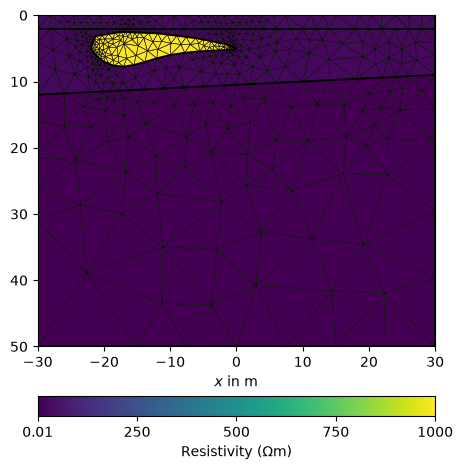

In [4]:
# assign resistivity to each layer defined by the marker number
# the list has two values
# first one is the marker number and the 2nd one is the corresponding resistivity value
rhomap = [[0, 20],
        [1, 30], 
        [2, 0.01], 
        [3, 1000]
       ]
pg.show(mesh, data=rhomap, showMesh=True, label = pg.unit('res'), logscale = True)

In [5]:
# import ert module to create synthetic data
from pygimli.physics import ert
import numpy as np

In [6]:
# put the electrodes and use any scheme of ERT array 
# dd is dipole-dipole
# check with other scheme, such as, 'wa' > Wenner-Alfa
scheme = ert.createData(elecs=np.linspace(-25, 25, 21), 
                       schemeName='dd') 

30/09/26 - 00:25:03 - pyGIMLi - INFO - Cache /home/jyotirmp/anaconda3/envs/pg/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.0s x 6): /home/jyotirmp/.cache/pygimli/17385885611949548145


In [7]:
#simulate synthetic data and save the data
#must introduce error in the data
synthetic_data = ert.simulate(mesh, scheme=scheme, res = rhomap, noiseLevel=1, noiseAbs=1e-6)
synthetic_data.remove(synthetic_data['rhoa'] < 0)
synthetic_data.save('syn_data2.dat')

30/09/26 - 00:25:03 - pyGIMLi - INFO - Data error estimate (min:max)  0.010000649509113656 : 0.018472090585589553


ModellingBase::setMesh() copying new mesh ... Found datafile: 21 electrodes
Found: 21 free-electrodes
rMin = 1.25, rMax = 100
NGauLeg + NGauLag for inverse Fouriertransformation: 11 + 4
Found non-Neumann domain
0.00983748 s
FOP updating mesh dependencies ... 3.043e-06 s
relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Calculating response for model: min = 0.01 max = 1000
Allocating memory for primary potential...... 0.000642129

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.095966s
Response: min = 6.43662 max = 190.795 mean = 36.4874
Reciprocity rms(modelReciprocity) 21.466%, max: 149.466%


1

In [8]:
#print the data
#check if all parameters are there
# must contain a, b, err, m,n, r, rhoa
print(synthetic_data)

Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x79d2782f49d0>)

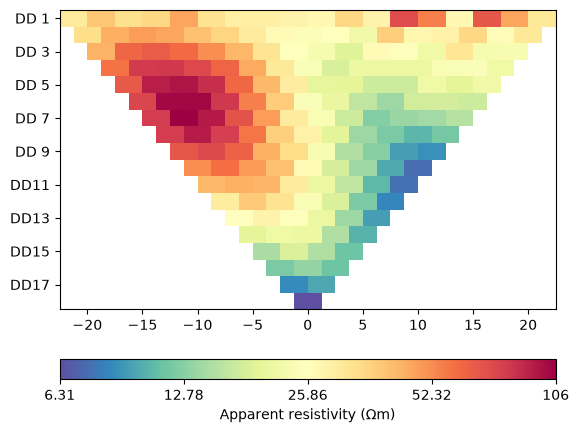

In [9]:
#produce pseudo-section
ert.show(synthetic_data)

In [10]:
#initiate ert Manager to invert the pseudo-section
mgr = ert.Manager('syn_data2.dat')
mgr.invert(verbose = True)

30/09/26 - 00:25:04 - pyGIMLi - INFO - Found 2 regions.
30/09/26 - 00:25:04 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
30/09/26 - 00:25:04 - pyGIMLi - INFO - Found 2 regions.
30/09/26 - 00:25:04 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
30/09/26 - 00:25:04 - pyGIMLi - INFO - Creating forward mesh from region infos.
30/09/26 - 00:25:04 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
30/09/26 - 00:25:04 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 997 Cells: 1848 Boundaries: 1458
30/09/26 - 00:25:04 - pyGIMLi - INFO - Use median(data values)=27.8434929220832
30/09/26 - 00:25:04 - pyGIMLi - INFO - Created startmodel from forward operator:287, min/max=27.843493/27.843493
30/09/26 - 00:25:04 - pyGIMLi - INFO - Starting inversion.
30/09/26 - 00:25:04 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x79d278157510>
30/09/26 - 00:25:04 - pyGIMLi - INFO - Data transf

Constructing Delaunay triangulation by divide-and-conquer method.
Delaunay milliseconds:  0
Recovering segments in Delaunay triangulation.
Segment milliseconds:  0
Removing unwanted triangles.
Spreading regional attributes and area constraints.
Hole milliseconds:  0
Adding Steiner points to enforce quality.
Quality milliseconds:  0

Writing vertices.
Writing triangles.
Writing segments.
Writing edges.

Output milliseconds:  0
Total running milliseconds:  0

Statistics:

  Input vertices: 49
  Input segments: 50
  Input holes: 0

  Mesh vertices: 268
  Mesh triangles: 462
  Mesh edges: 729
  Mesh exterior boundary edges: 72
  Mesh interior boundary edges: 15
  Mesh subsegments (constrained edges): 87

min/max(dweight) = 54.1357/99.9935
--------------------------------------------------------------------------------
Calculating response for model: min = 27.8435 max = 27.8435
Allocating memory for primary potential...... 0.000372162

No primary potential for secondary field calculation. C

30/09/26 - 00:25:05 - pyGIMLi - INFO - chi² =  561.93 (dPhi = 84.34%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 1 ... solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 0.0609581 max = 390.11
Using existing primary potentials.
Forward: time: 0.196962s
Response: min = 6.66463 max = 96.1676 mean = 28.6897
Reciprocity rms(modelReciprocity) 2.5639%, max: 5.72538%
1: LS newModel: min = 0.0609581; max = 390.11
1: LS newResponse: min = 6.56941; max = 96.2757
1: rms/rrms(data, LS newResponse) = 8.89482/22.5591%
1: chi^2(data, LS newResponse, error, log) = 730.486
1: Phi = 124913+146.391*20=127841
Performing line search with tau = 0.88
Calculating response for model: min = 0.127114 max = 284.192
Using existing primary potentials.
Forward: time: 0.194757s
Response: min = 7.62573 max = 85.0303 mean = 28.5271
Reciprocity rms(modelReciprocity) 2.15557%, max: 4.65064%
1: Model: min = 0.127114; max = 284.192
1: Response: min = 7.53812; max = 85.1328
1: rms/rrms(data, Response) = 9.75206/20.5058%
1:

30/09/26 - 00:25:05 - pyGIMLi - INFO - chi² =   54.42 (dPhi = 88.92%) lam: 20.0


...

30/09/26 - 00:25:07 - pyGIMLi - INFO - chi² =    2.99 (dPhi = 10.08%) lam: 20.0


Using existing primary potentials.
Forward: time: 0.202963s
Response: min = 6.75382 max = 103.287 mean = 34.8719
Reciprocity rms(modelReciprocity) 1.59268%, max: 3.5946%
4: LS newModel: min = 0.45838; max = 517.115
4: LS newResponse: min = 6.63839; max = 103.44
4: rms/rrms(data, LS newResponse) = 0.772235/1.83754%
4: chi^2(data, LS newResponse, error, log) = 3.05175
4: Phi = 521.85+91.6016*20=2353.88
Performing line search with tau = 0.82
Calculating response for model: min = 0.453705 max = 518.532
--------------------------------------------------------------------------------
inv.iter 5 ... Using existing primary potentials.
Forward: time: 0.198392s
Response: min = 6.80869 max = 103.366 mean = 34.8888
Reciprocity rms(modelReciprocity) 1.583%, max: 3.54547%
4: Model: min = 0.453705; max = 518.532
4: Response: min = 6.69212; max = 103.515
4: rms/rrms(data, Response) = 0.762591/1.84519%
4: chi^2(data, Response, error, log) = 2.98738
4: Phi = 510.842+91.3099*20=2337.04
Calculating Jacobi

30/09/26 - 00:25:07 - pyGIMLi - INFO - chi² =    2.91 (dPhi = 0.58%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 0.58 (< 2.0%)                 #
################################################################################
Using existing primary potentials.
Forward: time: 0.212834s
Response: min = 6.94501 max = 103.661 mean = 34.9901
Reciprocity rms(modelReciprocity) 1.57828%, max: 3.48876%
5: LS newModel: min = 0.467906; max = 519.337
5: LS newResponse: min = 6.82711; max = 103.808
5: rms/rrms(data, LS newResponse) = 0.710679/1.92547%
5: chi^2(data, LS newResponse, error, log) = 2.95597
5: Phi = 505.472+91.3228*20=2331.93
Performing line search with tau = 0.57
Calculating response for model: min = 0.461746 max = 518.991
Using existing primary potentials.
Forward: time: 0.206381s
Response: min = 6.88612 max = 103.534 mean = 34.9458
Reciprocity rms(modelReciprocity) 1.5799%, max: 3.514%
5: Model: min = 0.461746; max = 518.991
5: Response: min = 6.76881; max = 103.682

287 [33.24670148803713,...,2.3720066651830622]

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x79d278090f50>)

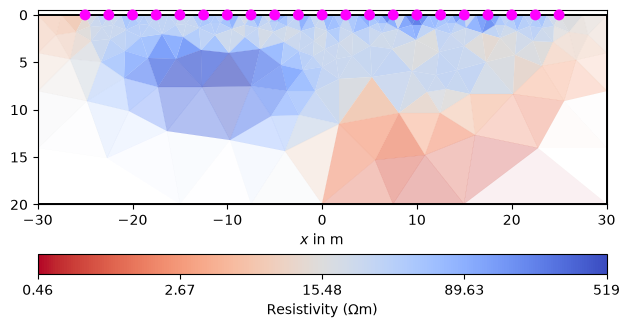

In [11]:
#visualize the inverted result

#import cmcrameri.cm as cmc
#mgr.showResult(logScale=True, cMap=cmc.vik)

mgr.showResult(cMap = 'coolwarm_r') #play with different colopr maps

#try scientific color mapping 
# to install, run
# pip install cmcrameri
## and import new colormaps
#import cmcrameri.cm as cmc
#mgr.showResult(logScale=True, cMap=cmc.vik)

(<Axes: xlabel='$x$ in m'>, None)

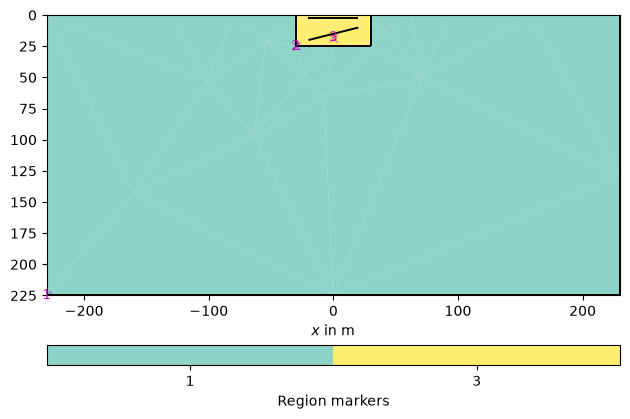

In [12]:
#improve the inverted data with geological knowledge

#create Piecewise Linear Complex (plc)
plc = mt.createParaMeshPLC(synthetic_data, paraDepth=25) 

#as we knew there are three different layers
# add those using two lines
line = mt.createLine(start = [-20, -20], end = [20, -10])
line2 = mt.createLine([-20,-2], [20, -2])
plc.addRegionMarker([0, -18], marker=3)
#make the plc geometry
plc += line
plc+= line2
pg.show(plc)

(<Axes: xlabel='$x$ in m'>, None)

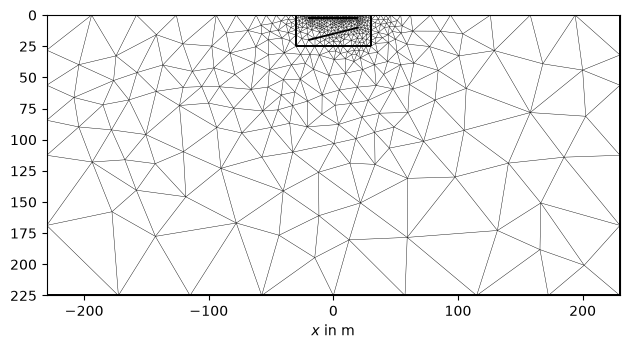

In [13]:
#create mesh for new plc
mesh = mt.createMesh(plc, quality = 34)
pg.show(mesh)

In [14]:
#incorporate the mesh within ert manager and invert
mgr.setMesh(mesh)
mgr.invert(verbose=True)

30/09/26 - 00:25:09 - pyGIMLi - INFO - Found 2 regions.
30/09/26 - 00:25:09 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Reset region parameter
RegionManager copying mesh ...0.00949175 s 
create NeighborInfos ... 2.3234e-05 s 
analyzing mesh ... 2 regions.
creating para domain ... 0.00326911 s


30/09/26 - 00:25:09 - pyGIMLi - INFO - Creating forward mesh from region infos.
30/09/26 - 00:25:09 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
30/09/26 - 00:25:09 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2127 Cells: 4080 Boundaries: 3146
30/09/26 - 00:25:09 - pyGIMLi - INFO - Use median(data values)=27.8434929220832
30/09/26 - 00:25:09 - pyGIMLi - INFO - Created startmodel from forward operator:602, min/max=27.843493/27.843493
30/09/26 - 00:25:09 - pyGIMLi - INFO - Starting inversion.
30/09/26 - 00:25:09 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x79d278157510>
30/09/26 - 00:25:09 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
30/09/26 - 00:25:09 - pyGIMLi - INFO - Model transformation: Logarithmic transform
30/09/26 - 00:25:09 - pyGIMLi - INFO - min/max (data): 6.31/106
30/09/26 - 00:25:09 - pyGIMLi - INFO - min/max (error): 1%/1.85%
30/09/26 - 00:25:09 - 

Found datafile: 21 electrodes
Found: 21 node-electrodes
Found non-Neumann domain
 updateDataDependency:: cleaning primpot
creating para domain ... 0.0045054 s
ModellingBase::setMesh() copying new mesh ... Found datafile: 21 electrodes
Found: 21 node-electrodes
Found non-Neumann domain
0.0215435 s
FOP updating mesh dependencies ... 1.2477e-05 s
ModellingBase::setMesh() copying new mesh ... 0.0192783 s
FOP updating mesh dependencies ... 2.9686e-05 s
min/max(dweight) = 54.1357/99.9935
--------------------------------------------------------------------------------
Calculating response for model: min = 27.8435 max = 27.8435
Allocating memory for primary potential...... 0.00061276

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.533447s
Response: min = 27.7608 max = 27.8797 mean = 27.8248
Reciprocity rms(modelReciprocity) 0%, max: 0%
min/max(dweight) = 54.1357/99.9935
Building constraints matrix
constraint matrix of size(nBounds x nModel) 8

30/09/26 - 00:25:10 - pyGIMLi - INFO - chi² =  400.49 (dPhi = 88.86%) lam: 20.0


...

30/09/26 - 00:25:16 - pyGIMLi - INFO - chi² =    2.49 (dPhi = 61.13%) lam: 20.0


Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.000713119:time: 0.260627s
sens sum: median = 1.60927 min = 0.932818 max = 3.90119
... 0.262907 s
solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 0.170429 max = 482.359
Using existing primary potentials.
Forward: time: 0.42385s
Response: min = 6.82397 max = 104.613 mean = 35.1429
Reciprocity rms(modelReciprocity) 0.619612%, max: 1.61159%
Performing line search with tau = 1
6: Model: min = 0.170429; max = 482.359
6: Response: min = 6.7908; max = 104.551
6: rms/rrms(data, Response) = 0.59658/1.81168%
6: chi^2(data, Response, error, log) = 2.49321
6: Phi = 426.339+67.1791*20=1769.92
--------------------------------------------------------------------------------
inv.iter 7 ... 

30/09/26 - 00:25:17 - pyGIMLi - INFO - chi² =    2.42 (dPhi = 1.76%) lam: 20.0


Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.000506415:time: 0.274242s
sens sum: median = 1.60046 min = 0.924558 max = 4.01162
... 0.275388 s
solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 0.453577 max = 469.566
Using existing primary potentials.
Forward: time: 0.415801s
Response: min = 7.15538 max = 103.828 mean = 35.0561
Reciprocity rms(modelReciprocity) 0.599001%, max: 1.50719%
tau = 0. Trying parabolic line search with step length 0.3Calculating response for model: min = 0.228599 max = 478.485
Using existing primary potentials.
Forward: time: 0.414204s
Response: min = 6.85005 max = 104.391 mean = 35.0959
Reciprocity rms(modelReciprocity) 0.613753%, max: 1.58927%
 ==> tau = 0.292456
7: LS newModel: min = 0.453577; max = 469.566
7: LS newResponse: min = 7.11948; max = 103.753
7: rms/rrms(data, LS newResponse) = 0.696004/2.38845%
7: chi^2(data, LS newResponse, error, log) = 3.70259
7: Phi = 633.

602 [2.262491770390247,...,9.66157331803046]

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x79d2779a4550>)

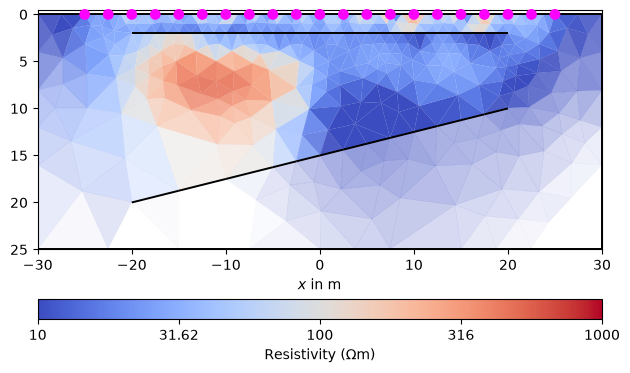

In [15]:
#visualize the final result
mgr.showResult(cMap = 'coolwarm', cMax = 1000, cMin = 10, logscale =True)

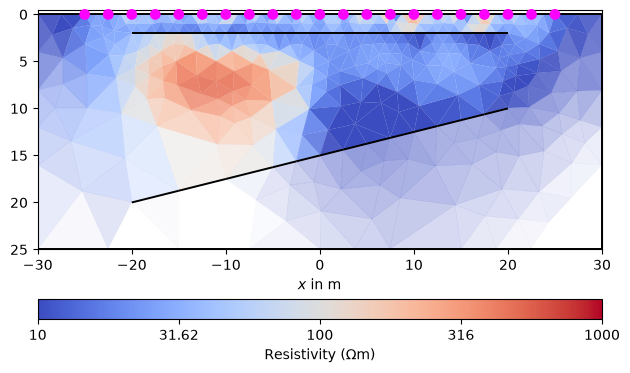

In [16]:
# to save figure
ax, cb = mgr.showResult(cMap='coolwarm', cMin=10, cMax=1000, logScale=True)
ax.figure.savefig("lake_result.png", dpi=300, bbox_inches="tight")